<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week8/day3-4/kMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP Gold - K-means from scratch

## What you will create
- A K-means implementation in pure NumPy.
- Scatter plots of clusters and centroid convergence.
- A report with cluster assignments per point.
- A random centroid initializer to study initialization impact.

## What you will learn
- Euclidean distance and closest-centroid assignment.
- How centroid updates reduce within-cluster variance.
- Why initialization matters and how to evaluate runs.


## Task 1 - Load and visualize the dataset
Dataset: `ex7data2.mat` contains an array `X` of shape (m, 2).

- Load with `scipy.io.loadmat`
- Inspect shape and preview first rows
- Scatter plot of points

Shape of X:  (300, 2)
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


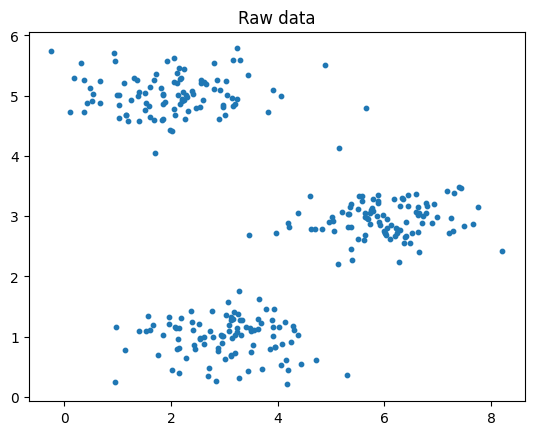

In [7]:
# TODO: load X from the .mat file
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)
#print(data)
# TODO: set X to the numpy array of points
X = data['X']
print('Shape of X: ', X.shape)
# TODO: preview first 5 rows
print(X[:5])

# TODO: scatter plot
plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title('Raw data')
plt.show()

## Task 2 - Finding closest centroids
Implement `find_closest_centroids(X, centroids)`.

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances

Test with initial centroids = `np.array([[3, 3], [6, 2], [8, 5]])` and print the first three indices.

In [9]:
def find_closest_centroids(X, centroids):
    X_expanded = X[:, np.newaxis, :]
    print("X expanded shape:", X_expanded.shape)          # (300, 1, 2)

    C_expanded = centroids[np.newaxis, :, :]
    print("Centroids expanded shape:", C_expanded.shape)  # (1, 3, 2)

    diff = X_expanded - C_expanded
    print("Diff shape:", diff.shape)                      # (300, 3, 2)

    distances = np.sum(diff ** 2, axis=2)
    print("Distances shape:", distances.shape)            # (300, 3)
    print("First 3 rows of distances:\n", distances[:3])  # distance to each centroid for first 3 points

    idx = np.argmin(distances, axis=1)
    print("First 3 idx:", idx[:3])                        # closest centroid index
    return idx

init_centroids = np.array([[3,3],[6,2],[8,5]], dtype=float)
idx = find_closest_centroids(X, init_centroids)

X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[ 3.92506628 24.0877323  38.07398455]
 [10.30793481  7.95636419  5.52224738]
 [11.32438176  1.79061723  5.63517456]]
First 3 idx: [0 2 1]


## Task 3 - Computing centroids
Implement `compute_centroids(X, idx, K)`.

- For each k in 0..K-1 compute the mean of points assigned to k
- Return `centroids` of shape (K, n)
- If a cluster is empty, reinitialize its centroid by sampling a random point from X

In [10]:
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    print(f"Computing centroids: {m} points, {n} features, {K} clusters")
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng

    for k in range(K):
        pts = X[idx == k]  # all points assigned to cluster k
        print(f"  Cluster {k}: {pts.shape[0]} points assigned")

        if pts.shape[0] == 0:
            # empty cluster — reinitialize with a random point from X
            new_centroids[k] = X[rng.integers(0, m)]
            print(f"  Cluster {k}: empty! reinitialized to {new_centroids[k]}")
        else:
            new_centroids[k] = pts.mean(axis=0)  # mean over all points → (n,)
            print(f"  Cluster {k}: centroid = {new_centroids[k]}")

    return new_centroids

idx_test = find_closest_centroids(X, init_centroids)
print(compute_centroids(X, idx_test, K=3))

X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[ 3.92506628 24.0877323  38.07398455]
 [10.30793481  7.95636419  5.52224738]
 [11.32438176  1.79061723  5.63517456]]
First 3 idx: [0 2 1]
Computing centroids: 300 points, 2 features, 3 clusters
  Cluster 0: 191 points assigned
  Cluster 0: centroid = [2.42830111 3.15792418]
  Cluster 1: 103 points assigned
  Cluster 1: centroid = [5.81350331 2.63365645]
  Cluster 2: 6 points assigned
  Cluster 2: centroid = [7.11938687 3.6166844 ]
[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


## Task 4 - Running K-means
Implement `run_k_means(X, init_centroids, max_iters)`.

- Loop: assign then update
- Keep history of centroids for plotting
- Return final centroids, idx, and history list
- Run for 10 iterations and plot clusters with final centroids


Iteration 1/10
X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[ 3.92506628 24.0877323  38.07398455]
 [10.30793481  7.95636419  5.52224738]
 [11.32438176  1.79061723  5.63517456]]
First 3 idx: [0 2 1]
  Cluster counts: {0: 191, 1: 103, 2: 6}
Computing centroids: 300 points, 2 features, 3 clusters
  Cluster 0: 191 points assigned
  Cluster 0: centroid = [2.42830111 3.15792418]
  Cluster 1: 103 points assigned
  Cluster 1: centroid = [5.81350331 2.63365645]
  Cluster 2: 6 points assigned
  Cluster 2: centroid = [7.11938687 3.6166844 ]
  New centroids:
[[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]

Iteration 2/10
X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[ 2.44513341 19.66854785 28.83183022]
 [13.13101681  4.7168889   3.53409834]
 [15.41762679  0.72251179  0.694

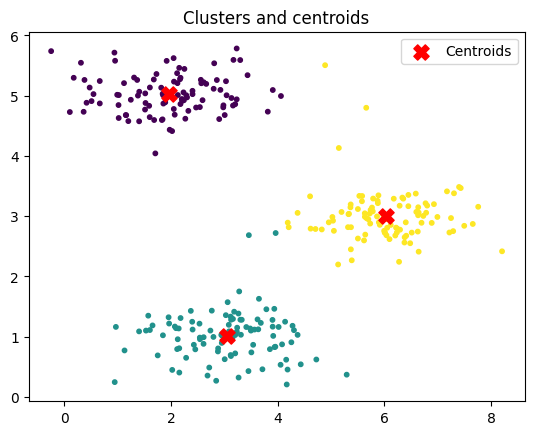

In [11]:
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None

    for it in range(max_iters):
        print(f"\nIteration {it+1}/{max_iters}")

        idx = find_closest_centroids(X, centroids)          # assign each point to closest centroid
        print(f"  Cluster counts: { {k: int((idx==k).sum()) for k in range(K)} }")

        centroids = compute_centroids(X, idx, K, rng=rng)   # recompute centroids as cluster means
        history.append(centroids.copy())                     # save for plotting
        print(f"  New centroids:\n{centroids}")

    return centroids, idx, history

# Run
final_centroids, idx, hist = run_k_means(X, init_centroids, max_iters=10)

# Plot
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=idx, s=10, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], marker='X', s=120, c='red', label='Centroids')
plt.title('Clusters and centroids')
plt.legend()
plt.show()

## Task 5 - Initializing centroids
Implement `init_centroids(X, K, rng)` that picks K distinct random points from X.

Test by printing initial centroids for K = 3.

In [12]:
# TODO: implement
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)  # K distinct random indices
    return X[idx].astype(float)

print(init_centroids(X, 3))

[[1.40597916 5.06636822]
 [3.1189017  0.69438336]
 [3.6834465  1.22834538]]


## Task 6 - Multiple initializations and evaluation
Define an inertia function `withinss(X, centroids, idx)` to compute the sum of squared distances to centroids.

- Run K-means for several random seeds
- Keep the run with lowest inertia
- Save a CSV report with x1, x2, cluster label

In [14]:
# TODO: implement inertia and multi-start search
import pandas as pd

def withinss(X, centroids, idx):
    diffs = X - centroids[idx]          # each point minus its assigned centroid → (m, n)
    return float(np.sum(diffs * diffs)) # sum of all squared distances

best = {'score': np.inf}
for seed in range(5):
    rng = np.random.default_rng(seed)
    c0 = init_centroids(X, 3, rng)
    cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
    s = withinss(X, cF, idxF)
    print(f"Seed {seed}: inertia = {s:.2f}")
    if s < best['score']:
        best = {'score': s, 'centroids': cF, 'idx': idxF}

print('Best inertia:', best['score'])

rep = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'cluster': best['idx']})
rep.to_csv('kmeans_assignments.csv', index=False)
print('Wrote kmeans_assignments.csv')


Iteration 1/10
X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[14.02343929 14.12446217 27.8410337 ]
 [21.6005194  21.58881885  4.17060302]
 [16.74498898 16.68382411  0.33853934]]
First 3 idx: [0 2 2]
  Cluster counts: {0: 134, 1: 62, 2: 104}
Computing centroids: 300 points, 2 features, 3 clusters
  Cluster 0: 134 points assigned
  Cluster 0: centroid = [1.98134296 3.76342513]
  Cluster 1: 62 points assigned
  Cluster 1: centroid = [3.61765375 1.02268053]
  Cluster 2: 104 points assigned
  Cluster 2: centroid = [5.91844409 3.15793345]
  New centroids:
[[1.98134296 3.76342513]
 [3.61765375 1.02268053]
 [5.91844409 3.15793345]]

Iteration 2/10
X expanded shape: (300, 1, 2)
Centroids expanded shape: (1, 3, 2)
Diff shape: (300, 3, 2)
Distances shape: (300, 3)
First 3 rows of distances:
 [[ 0.73197758 16.00410783 18.71819876]
 [14.59650814 18.43326349  2.76379223]
 [19.33102681 12.62442881  0.2